# 02. Exploratory Data Analysis (EDA) - Descriptive Statistics

**Goal:** Understand the distribution of key variables (Revenue, Budget, ROI, Ratings) after cleaning.

**Steps:**
1. Load Processed Data
2. Basic Statistics
3. Distributions (Histograms)
4. Correlation Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
from pathlib import Path

# Set visualization style
sns.set(style="whitegrid")

# Configure pandas display options for readable numbers (no scientific notation)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path(os.getcwd())

if NOTEBOOK_DIR.name == 'notebooks':
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    PROJECT_DIR = NOTEBOOK_DIR

PROCESSED_DATA_PATH = PROJECT_DIR / 'data' / 'processed' / 'clean_tmdb_movies.csv'
PROCESSED_DATA_PATH = str(PROCESSED_DATA_PATH)
print(f'Path: {PROCESSED_DATA_PATH}')

Path: /Users/ljh2578922967/Documents/Courseware/Sem2/7400/Group/AIDM7400_Group_Project/data/processed/clean_tmdb_movies.csv


In [3]:
# 1. Load Processed Data
if os.path.exists(PROCESSED_DATA_PATH):
    df = pd.read_csv(PROCESSED_DATA_PATH)
    
    # Convert date back to datetime
    df['release_date'] = pd.to_datetime(df['release_date'])
    
    # Handle list columns (they load as strings from CSV)
    list_cols = ['genres', 'production_companies', 'production_countries', 'spoken_languages']
    for col in list_cols:
        # Use literal_eval to convert string "['Action', 'Comedy']" back to list
        # Handle NaN potential
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
    
    print(f"Loaded Clean Data: {df.shape}")
    display(df.head(2))
else:
    print("Processed data not found! Please run 01_Data_Cleaning.ipynb first.")

Loaded Clean Data: (5646, 28)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,tagline,genres,production_companies,production_countries,spoken_languages,keywords,release_year,release_month,release_quarter,roi
0,27205,Inception,8.36,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Your mind is the scene of the crime.,"[Action, Science Fiction, Adventure]","[Legendary Pictures, Syncopy, Warner Bros. Pic...","[United Kingdom, United States of America]","[English, French, Japanese, Swahili]","rescue, mission, dream, airplane, paris, franc...",2010.00,7.00,3.00,4.16
1,157336,Interstellar,8.42,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Mankind was born on Earth. It was never meant ...,"[Adventure, Drama, Science Fiction]","[Legendary Pictures, Syncopy, Lynda Obst Produ...","[United Kingdom, United States of America]",[English],"rescue, future, spacecraft, race against time,...",2014.00,11.00,4.00,3.25


In [4]:
# 2. Basic Statistics
desc_stats = df[['budget', 'revenue', 'roi', 'vote_average', 'vote_count', 'runtime']].describe()
display(desc_stats)

,budget,revenue,roi,vote_average,vote_count,runtime
count,5646.00,5646.00,5646.00,5646.00,5646.00,5646.00
mean,29923784.56,85483204.23,2.02,6.13,1819.85,109.38
std,48712490.23,199981443.37,4.57,1.67,3310.55,42.08
min,10850.00,10018.00,-1.00,0.00,0.00,0.00
25%,3000000.00,1922692.25,-0.41,5.75,59.00,94.00
50%,12000000.00,14705307.00,0.65,6.40,512.00,106.00
75%,34450000.00,75678963.25,2.51,7.00,1999.50,122.00
max,800000000.00,3000000000.00,46.18,10.00,34495.00,999.00


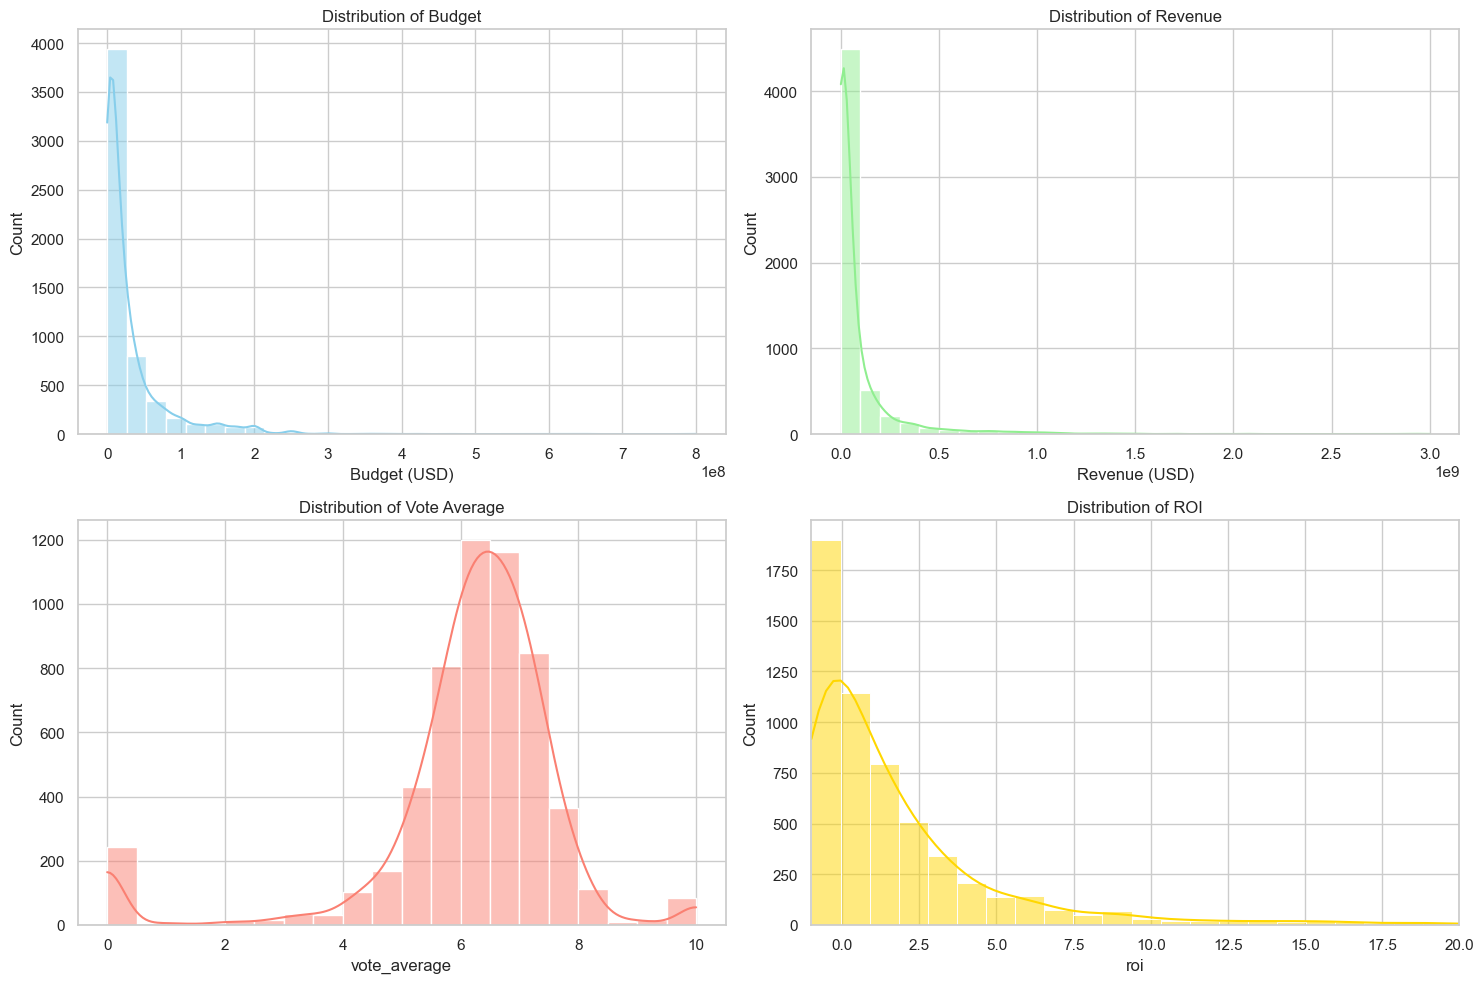

In [5]:
# 3. Distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Budget
sns.histplot(df['budget'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribution of Budget')
axes[0,0].set_xlabel('Budget (USD)')

# Revenue
sns.histplot(df['revenue'], bins=30, kde=True, ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Distribution of Revenue')
axes[0,1].set_xlabel('Revenue (USD)')

# Vote Average
sns.histplot(df['vote_average'], bins=20, kde=True, ax=axes[1,0], color='salmon')
axes[1,0].set_title('Distribution of Vote Average')

# ROI (Limit range for visibility as outliers exist)
sns.histplot(df['roi'], bins=50, kde=True, ax=axes[1,1], color='gold')
axes[1,1].set_title('Distribution of ROI')
axes[1,1].set_xlim(-1, 20) # Focusing on common range [-100% to 2000%]

plt.tight_layout()
plt.show()

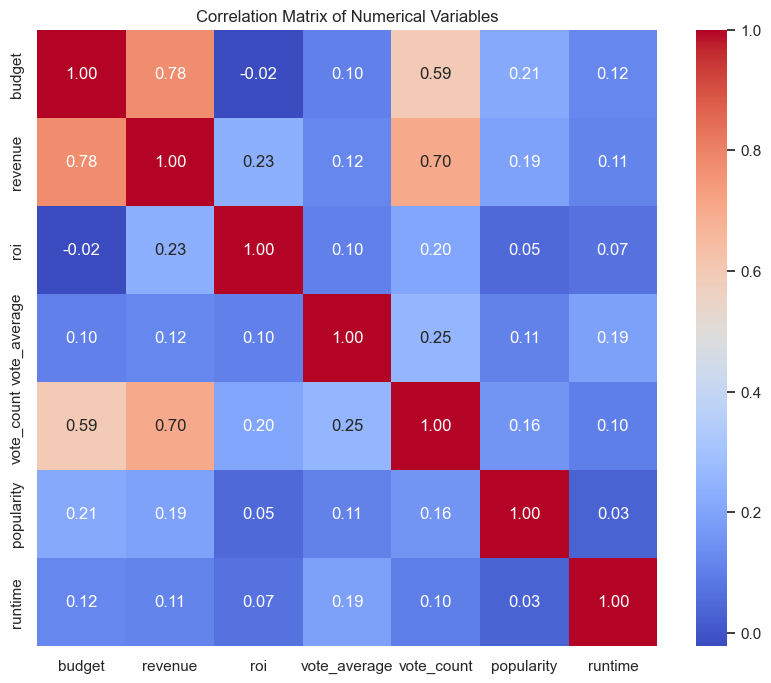

In [6]:
# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df[['budget', 'revenue', 'roi', 'vote_average', 'vote_count', 'popularity', 'runtime']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

/var/folders/yn/n87g5w9s63s668kv8lb_2hzh0000gn/T/ipykernel_60971/1483587683.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


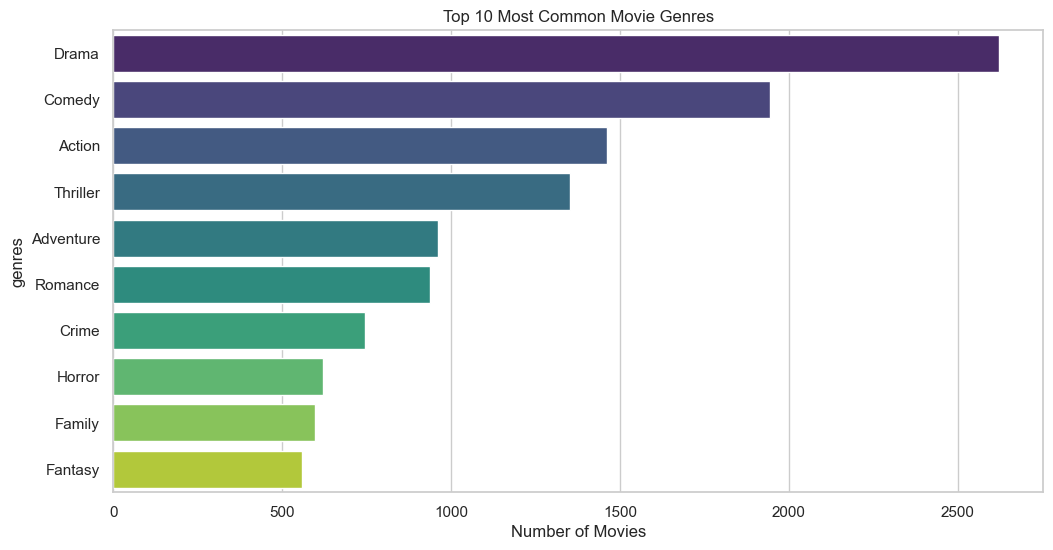

In [7]:
# 5. Top Genres (Quick Look)
# Explode the genres column to count individual genres
genre_df = df.explode('genres')
genre_counts = genre_df['genres'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Most Common Movie Genres')
plt.xlabel('Number of Movies')
plt.show()